# EDA Fase 3 — Validación de los 21 Arquetipos de Usuario

**Objetivo:** ¿Están los 21 arquetipos suficientemente diferenciados entre sí?
Si dos arquetipos son casi idénticos, el modelo no podrá distinguirlos y los
perfiles sintéticos que generen serán redundantes.

**¿Por qué importa esto antes de generar perfiles sintéticos?**
Los 21 arquetipos son los "moldes" que generamos con distribuciones beta para
crear 5.000 perfiles de usuario. Si dos moldes son casi iguales, estaremos
generando datos duplicados que no aportan nueva información al modelo pero
consumen capacidad del dataset de entrenamiento.

Este notebook responde tres preguntas:
1. ¿Qué perfil tiene cada arquetipo en las 26 dimensiones?
2. ¿Qué pares de arquetipos son más similares entre sí?
3. ¿Hay arquetipos que deberían fusionarse o diferenciarse más?


## Paso 0 — Definir la matriz de arquetipos


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import dendrogram, linkage
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=0.9)
ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
OUT  = ROOT / 'data' / 'processed'

# -- Valores de referencia
H = 0.85  # HIGH   -- dimension esencial para este arquetipo
M = 0.50  # MEDIUM -- dimension relevante pero no central
L = 0.10  # LOW    -- dimension irrelevante o activamente evitada
N = 0.25  # NOT MENTIONED -- neutral-bajo

DIMS = ['gastronomia', 'vida_nocturna', 'cultura', 'arte_visual', 'naturaleza', 'deporte_agua', 'deporte_montana', 'deporte_urbano', 'bienestar', 'familia', 'mascotas', 'nomada', 'alojamiento', 'movilidad', 'compras', 'servicios', 'salud', 'turismo', 'educacion', 'comunidad', 'coste', 'clima', 'calidad_vida', 'social_media', 'musica', 'autenticidad']

ARCHETYPES = {
    "kite_surf": {"gastronomia": 0.25, "vida_nocturna": 0.1, "cultura": 0.25, "arte_visual": 0.1, "naturaleza": 0.85, "deporte_agua": 0.85, "deporte_montana": 0.25, "deporte_urbano": 0.5, "bienestar": 0.25, "familia": 0.1, "mascotas": 0.25, "nomada": 0.1, "alojamiento": 0.25, "movilidad": 0.5, "compras": 0.25, "servicios": 0.1, "salud": 0.1, "turismo": 0.25, "educacion": 0.1, "comunidad": 0.1, "coste": 0.5, "clima": 0.85, "calidad_vida": 0.25, "social_media": 0.5, "musica": 0.1, "autenticidad": 0.5},
    "deportista_outdoor": {"gastronomia": 0.5, "vida_nocturna": 0.1, "cultura": 0.25, "arte_visual": 0.1, "naturaleza": 0.85, "deporte_agua": 0.5, "deporte_montana": 0.85, "deporte_urbano": 0.85, "bienestar": 0.5, "familia": 0.1, "mascotas": 0.25, "nomada": 0.1, "alojamiento": 0.25, "movilidad": 0.5, "compras": 0.1, "servicios": 0.1, "salud": 0.5, "turismo": 0.25, "educacion": 0.25, "comunidad": 0.25, "coste": 0.25, "clima": 0.85, "calidad_vida": 0.25, "social_media": 0.1, "musica": 0.25, "autenticidad": 0.5},
    "ski_nieve": {"gastronomia": 0.5, "vida_nocturna": 0.1, "cultura": 0.25, "arte_visual": 0.25, "naturaleza": 0.85, "deporte_agua": 0.1, "deporte_montana": 0.85, "deporte_urbano": 0.5, "bienestar": 0.5, "familia": 0.1, "mascotas": 0.25, "nomada": 0.1, "alojamiento": 0.5, "movilidad": 0.25, "compras": 0.25, "servicios": 0.25, "salud": 0.25, "turismo": 0.25, "educacion": 0.25, "comunidad": 0.1, "coste": 0.25, "clima": 0.1, "calidad_vida": 0.5, "social_media": 0.1, "musica": 0.1, "autenticidad": 0.5},
    "nomada_barato": {"gastronomia": 0.5, "vida_nocturna": 0.5, "cultura": 0.25, "arte_visual": 0.1, "naturaleza": 0.25, "deporte_agua": 0.1, "deporte_montana": 0.1, "deporte_urbano": 0.25, "bienestar": 0.25, "familia": 0.1, "mascotas": 0.1, "nomada": 0.85, "alojamiento": 0.5, "movilidad": 0.5, "compras": 0.25, "servicios": 0.1, "salud": 0.25, "turismo": 0.25, "educacion": 0.25, "comunidad": 0.5, "coste": 0.85, "clima": 0.25, "calidad_vida": 0.85, "social_media": 0.1, "musica": 0.25, "autenticidad": 0.5},
    "nomada_premium": {"gastronomia": 0.85, "vida_nocturna": 0.5, "cultura": 0.5, "arte_visual": 0.25, "naturaleza": 0.25, "deporte_agua": 0.1, "deporte_montana": 0.1, "deporte_urbano": 0.85, "bienestar": 0.5, "familia": 0.1, "mascotas": 0.1, "nomada": 0.85, "alojamiento": 0.85, "movilidad": 0.5, "compras": 0.25, "servicios": 0.25, "salud": 0.25, "turismo": 0.25, "educacion": 0.25, "comunidad": 0.25, "coste": 0.1, "clima": 0.25, "calidad_vida": 0.85, "social_media": 0.1, "musica": 0.25, "autenticidad": 0.1},
    "nomada_mujer_activa": {"gastronomia": 0.5, "vida_nocturna": 0.1, "cultura": 0.25, "arte_visual": 0.1, "naturaleza": 0.5, "deporte_agua": 0.5, "deporte_montana": 0.25, "deporte_urbano": 0.85, "bienestar": 0.85, "familia": 0.1, "mascotas": 0.5, "nomada": 0.85, "alojamiento": 0.25, "movilidad": 0.25, "compras": 0.1, "servicios": 0.25, "salud": 0.25, "turismo": 0.25, "educacion": 0.5, "comunidad": 0.85, "coste": 0.25, "clima": 0.25, "calidad_vida": 0.25, "social_media": 0.1, "musica": 0.5, "autenticidad": 0.5},
    "cultura_arte": {"gastronomia": 0.5, "vida_nocturna": 0.5, "cultura": 0.85, "arte_visual": 0.85, "naturaleza": 0.25, "deporte_agua": 0.1, "deporte_montana": 0.1, "deporte_urbano": 0.25, "bienestar": 0.25, "familia": 0.1, "mascotas": 0.1, "nomada": 0.1, "alojamiento": 0.25, "movilidad": 0.5, "compras": 0.25, "servicios": 0.25, "salud": 0.25, "turismo": 0.85, "educacion": 0.25, "comunidad": 0.25, "coste": 0.1, "clima": 0.25, "calidad_vida": 0.5, "social_media": 0.1, "musica": 0.5, "autenticidad": 0.5},
    "musico_festivales": {"gastronomia": 0.5, "vida_nocturna": 0.85, "cultura": 0.85, "arte_visual": 0.5, "naturaleza": 0.25, "deporte_agua": 0.1, "deporte_montana": 0.1, "deporte_urbano": 0.25, "bienestar": 0.25, "familia": 0.1, "mascotas": 0.1, "nomada": 0.1, "alojamiento": 0.25, "movilidad": 0.5, "compras": 0.25, "servicios": 0.25, "salud": 0.25, "turismo": 0.5, "educacion": 0.25, "comunidad": 0.85, "coste": 0.25, "clima": 0.25, "calidad_vida": 0.25, "social_media": 0.1, "musica": 0.85, "autenticidad": 0.5},
    "gastronomia_vino": {"gastronomia": 0.85, "vida_nocturna": 0.5, "cultura": 0.1, "arte_visual": 0.1, "naturaleza": 0.25, "deporte_agua": 0.1, "deporte_montana": 0.1, "deporte_urbano": 0.25, "bienestar": 0.25, "familia": 0.1, "mascotas": 0.1, "nomada": 0.1, "alojamiento": 0.25, "movilidad": 0.5, "compras": 0.25, "servicios": 0.25, "salud": 0.25, "turismo": 0.85, "educacion": 0.25, "comunidad": 0.25, "coste": 0.1, "clima": 0.25, "calidad_vida": 0.5, "social_media": 0.1, "musica": 0.5, "autenticidad": 0.85},
    "antitur": {"gastronomia": 0.85, "vida_nocturna": 0.1, "cultura": 0.5, "arte_visual": 0.1, "naturaleza": 0.85, "deporte_agua": 0.1, "deporte_montana": 0.25, "deporte_urbano": 0.25, "bienestar": 0.25, "familia": 0.1, "mascotas": 0.25, "nomada": 0.1, "alojamiento": 0.25, "movilidad": 0.5, "compras": 0.25, "servicios": 0.25, "salud": 0.25, "turismo": 0.5, "educacion": 0.25, "comunidad": 0.5, "coste": 0.1, "clima": 0.25, "calidad_vida": 0.5, "social_media": 0.1, "musica": 0.25, "autenticidad": 0.85},
    "influencer": {"gastronomia": 0.85, "vida_nocturna": 0.85, "cultura": 0.5, "arte_visual": 0.85, "naturaleza": 0.25, "deporte_agua": 0.5, "deporte_montana": 0.1, "deporte_urbano": 0.25, "bienestar": 0.1, "familia": 0.1, "mascotas": 0.1, "nomada": 0.1, "alojamiento": 0.25, "movilidad": 0.5, "compras": 0.25, "servicios": 0.25, "salud": 0.1, "turismo": 0.85, "educacion": 0.1, "comunidad": 0.25, "coste": 0.25, "clima": 0.25, "calidad_vida": 0.25, "social_media": 0.85, "musica": 0.25, "autenticidad": 0.5},
    "familia_bebe": {"gastronomia": 0.5, "vida_nocturna": 0.1, "cultura": 0.25, "arte_visual": 0.1, "naturaleza": 0.25, "deporte_agua": 0.1, "deporte_montana": 0.25, "deporte_urbano": 0.25, "bienestar": 0.5, "familia": 0.85, "mascotas": 0.25, "nomada": 0.1, "alojamiento": 0.85, "movilidad": 0.85, "compras": 0.5, "servicios": 0.5, "salud": 0.85, "turismo": 0.25, "educacion": 0.25, "comunidad": 0.25, "coste": 0.25, "clima": 0.5, "calidad_vida": 0.85, "social_media": 0.1, "musica": 0.1, "autenticidad": 0.1},
    "familia_ninos": {"gastronomia": 0.25, "vida_nocturna": 0.1, "cultura": 0.25, "arte_visual": 0.25, "naturaleza": 0.25, "deporte_agua": 0.1, "deporte_montana": 0.25, "deporte_urbano": 0.25, "bienestar": 0.5, "familia": 0.85, "mascotas": 0.25, "nomada": 0.1, "alojamiento": 0.5, "movilidad": 0.85, "compras": 0.5, "servicios": 0.5, "salud": 0.85, "turismo": 0.5, "educacion": 0.85, "comunidad": 0.5, "coste": 0.25, "clima": 0.5, "calidad_vida": 0.85, "social_media": 0.1, "musica": 0.1, "autenticidad": 0.1},
    "fiesta_social": {"gastronomia": 0.85, "vida_nocturna": 0.85, "cultura": 0.25, "arte_visual": 0.25, "naturaleza": 0.25, "deporte_agua": 0.5, "deporte_montana": 0.1, "deporte_urbano": 0.25, "bienestar": 0.5, "familia": 0.1, "mascotas": 0.25, "nomada": 0.1, "alojamiento": 0.25, "movilidad": 0.25, "compras": 0.25, "servicios": 0.25, "salud": 0.1, "turismo": 0.1, "educacion": 0.1, "comunidad": 0.5, "coste": 0.25, "clima": 0.25, "calidad_vida": 0.25, "social_media": 0.85, "musica": 0.85, "autenticidad": 0.5},
    "bienestar_retiro": {"gastronomia": 0.1, "vida_nocturna": 0.1, "cultura": 0.25, "arte_visual": 0.25, "naturaleza": 0.85, "deporte_agua": 0.1, "deporte_montana": 0.25, "deporte_urbano": 0.5, "bienestar": 0.85, "familia": 0.1, "mascotas": 0.1, "nomada": 0.1, "alojamiento": 0.25, "movilidad": 0.25, "compras": 0.25, "servicios": 0.25, "salud": 0.5, "turismo": 0.1, "educacion": 0.1, "comunidad": 0.25, "coste": 0.25, "clima": 0.85, "calidad_vida": 0.85, "social_media": 0.1, "musica": 0.25, "autenticidad": 0.5},
    "jubilado_activo": {"gastronomia": 0.85, "vida_nocturna": 0.1, "cultura": 0.25, "arte_visual": 0.1, "naturaleza": 0.5, "deporte_agua": 0.25, "deporte_montana": 0.1, "deporte_urbano": 0.25, "bienestar": 0.85, "familia": 0.25, "mascotas": 0.25, "nomada": 0.1, "alojamiento": 0.25, "movilidad": 0.85, "compras": 0.5, "servicios": 0.25, "salud": 0.85, "turismo": 0.5, "educacion": 0.25, "comunidad": 0.5, "coste": 0.25, "clima": 0.85, "calidad_vida": 0.85, "social_media": 0.1, "musica": 0.1, "autenticidad": 0.5},
    "senior_accesibilidad": {"gastronomia": 0.5, "vida_nocturna": 0.1, "cultura": 0.25, "arte_visual": 0.1, "naturaleza": 0.25, "deporte_agua": 0.1, "deporte_montana": 0.1, "deporte_urbano": 0.25, "bienestar": 0.25, "familia": 0.25, "mascotas": 0.25, "nomada": 0.1, "alojamiento": 0.25, "movilidad": 0.85, "compras": 0.5, "servicios": 0.85, "salud": 0.85, "turismo": 0.5, "educacion": 0.25, "comunidad": 0.5, "coste": 0.25, "clima": 0.85, "calidad_vida": 0.85, "social_media": 0.1, "musica": 0.25, "autenticidad": 0.1},
    "mochilero_barato": {"gastronomia": 0.5, "vida_nocturna": 0.5, "cultura": 0.25, "arte_visual": 0.1, "naturaleza": 0.85, "deporte_agua": 0.25, "deporte_montana": 0.25, "deporte_urbano": 0.25, "bienestar": 0.1, "familia": 0.1, "mascotas": 0.25, "nomada": 0.25, "alojamiento": 0.25, "movilidad": 0.85, "compras": 0.1, "servicios": 0.1, "salud": 0.1, "turismo": 0.5, "educacion": 0.1, "comunidad": 0.5, "coste": 0.85, "clima": 0.25, "calidad_vida": 0.25, "social_media": 0.1, "musica": 0.25, "autenticidad": 0.85},
    "cosmopolita_urbano": {"gastronomia": 0.85, "vida_nocturna": 0.5, "cultura": 0.85, "arte_visual": 0.5, "naturaleza": 0.1, "deporte_agua": 0.1, "deporte_montana": 0.1, "deporte_urbano": 0.25, "bienestar": 0.25, "familia": 0.25, "mascotas": 0.1, "nomada": 0.25, "alojamiento": 0.25, "movilidad": 0.85, "compras": 0.5, "servicios": 0.5, "salud": 0.25, "turismo": 0.5, "educacion": 0.25, "comunidad": 0.5, "coste": 0.1, "clima": 0.25, "calidad_vida": 0.85, "social_media": 0.25, "musica": 0.25, "autenticidad": 0.1},
    "gamer_nomada_tech": {"gastronomia": 0.5, "vida_nocturna": 0.5, "cultura": 0.5, "arte_visual": 0.25, "naturaleza": 0.1, "deporte_agua": 0.1, "deporte_montana": 0.1, "deporte_urbano": 0.25, "bienestar": 0.25, "familia": 0.1, "mascotas": 0.1, "nomada": 0.85, "alojamiento": 0.25, "movilidad": 0.5, "compras": 0.25, "servicios": 0.25, "salud": 0.25, "turismo": 0.25, "educacion": 0.25, "comunidad": 0.85, "coste": 0.1, "clima": 0.25, "calidad_vida": 0.85, "social_media": 0.1, "musica": 0.25, "autenticidad": 0.5},
    "mascotas_naturaleza": {"gastronomia": 0.5, "vida_nocturna": 0.1, "cultura": 0.25, "arte_visual": 0.1, "naturaleza": 0.85, "deporte_agua": 0.5, "deporte_montana": 0.25, "deporte_urbano": 0.5, "bienestar": 0.85, "familia": 0.25, "mascotas": 0.85, "nomada": 0.1, "alojamiento": 0.25, "movilidad": 0.25, "compras": 0.1, "servicios": 0.25, "salud": 0.25, "turismo": 0.25, "educacion": 0.1, "comunidad": 0.25, "coste": 0.25, "clima": 0.5, "calidad_vida": 0.85, "social_media": 0.1, "musica": 0.25, "autenticidad": 0.5},
}

ARCH_LABELS = ['kite_surf', 'deportista_outdoor', 'ski_nieve', 'nomada_barato', 'nomada_premium', 'nomada_mujer_activa', 'cultura_arte', 'musico_festivales', 'gastronomia_vino', 'antitur', 'influencer', 'familia_bebe', 'familia_ninos', 'fiesta_social', 'bienestar_retiro', 'jubilado_activo', 'senior_acc', 'mochilero_barato', 'cosmopolita_urbano', 'gamer_tech', 'mascotas_nat']

# Construir DataFrame 21x26
df = pd.DataFrame(ARCHETYPES, index=DIMS).T
df.index = ARCH_LABELS
print(f"Matriz de arquetipos: {df.shape[0]} arquetipos x {df.shape[1]} dimensiones")
print(df.round(2).to_string())


Matriz de arquetipos: 21 arquetipos x 26 dimensiones
                     gastronomia  vida_nocturna  cultura  arte_visual  naturaleza  deporte_agua  deporte_montana  deporte_urbano  bienestar  familia  mascotas  nomada  alojamiento  movilidad  compras  servicios  salud  turismo  educacion  comunidad  coste  clima  calidad_vida  social_media  musica  autenticidad
kite_surf                   0.25           0.10     0.25         0.10        0.85          0.85             0.25            0.50       0.25     0.10      0.25    0.10         0.25       0.50     0.25       0.10   0.10     0.25       0.10       0.10   0.50   0.85          0.25          0.50    0.10          0.50
deportista_outdoor          0.50           0.10     0.25         0.10        0.85          0.50             0.85            0.85       0.50     0.10      0.25    0.10         0.25       0.50     0.10       0.10   0.50     0.25       0.25       0.25   0.25   0.85          0.25          0.10    0.25          0.50
ski_niev

## Paso 1 — Heatmap 21 arquetipos × 26 dimensiones


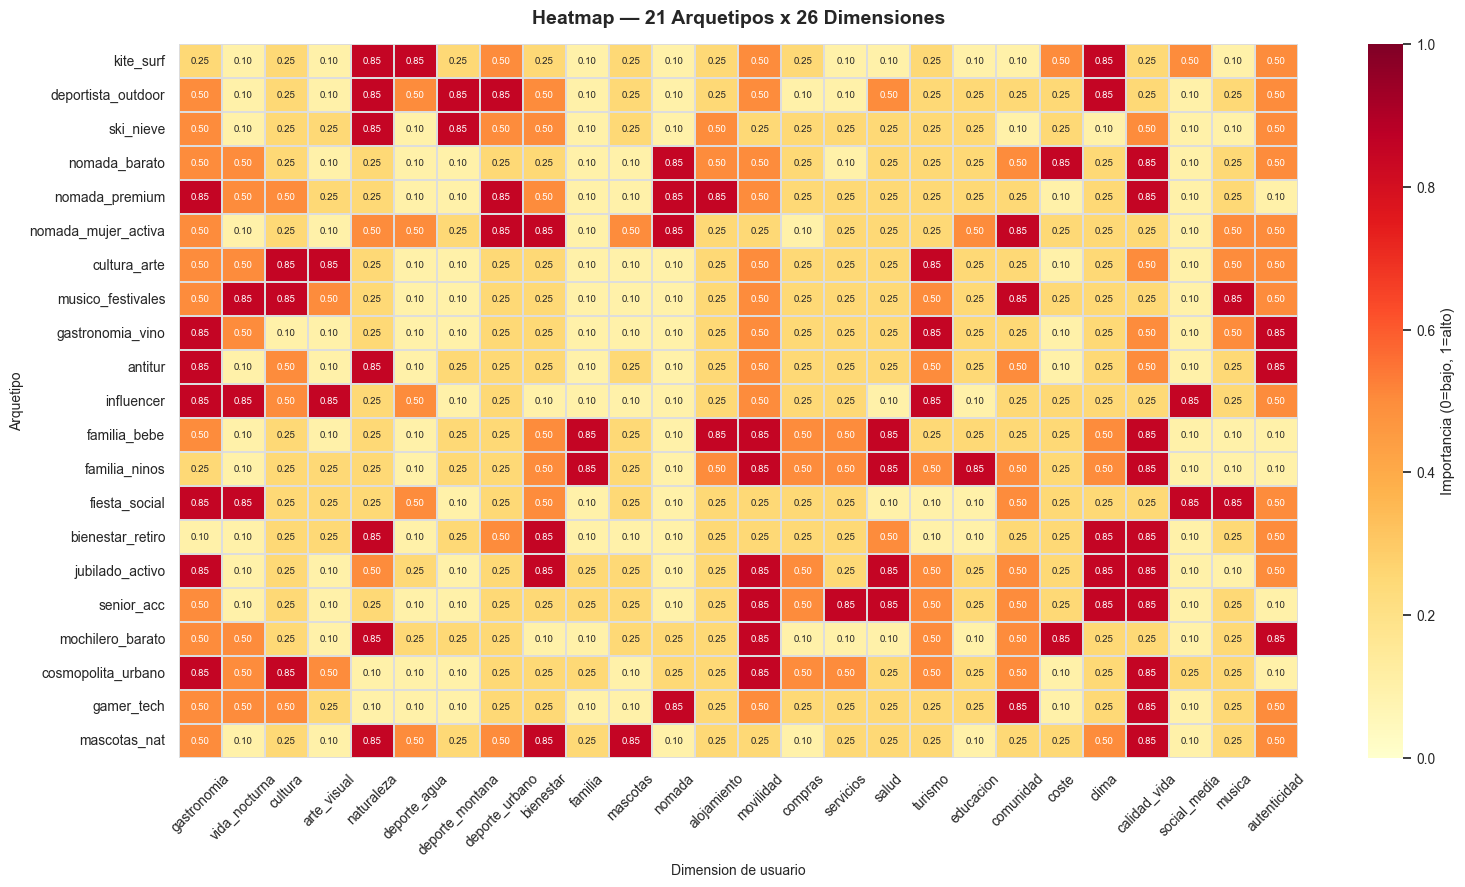

[OK] Guardado: eda_fase3_heatmap_arquetipos.png


In [2]:
fig, ax = plt.subplots(figsize=(16, 9))

# Colores: rojo = importante, amarillo = medio, blanco = bajo
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    df, ax=ax,
    annot=True, fmt='.2f', annot_kws={"size": 7},
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.3, linecolor='#dddddd',
    cbar_kws={'label': 'Importancia (0=bajo, 1=alto)'}
)
ax.set_title('Heatmap — 21 Arquetipos x 26 Dimensiones', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Dimension de usuario', fontsize=10)
ax.set_ylabel('Arquetipo', fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUT / 'eda_fase3_heatmap_arquetipos.png', dpi=130, bbox_inches='tight')
plt.show()
print("[OK] Guardado: eda_fase3_heatmap_arquetipos.png")


**PARA QUE SIRVE ESTE GRAFICO:**
Un heatmap de la matriz de arquetipos es el mapa completo de "quién valora qué".
Cada fila es un arquetipo, cada columna una dimensión de usuario, y el color indica
la importancia asignada (rojo oscuro = muy importante para ese arquetipo, blanco = no le importa).

**QUE NOS ESTA MOSTRANDO:**
- Las celdas rojas oscuras definen la identidad de cada arquetipo.
- Los arquetipos con pocas celdas rojas (ski_nieve, gamer_tech) tienen un perfil muy especializado.
- Los arquetipos con muchas celdas rojas-medias (cosmopolita_urbano, jubilado_activo) son más generalistas.
- Las columnas con muchos valores altos son dimensiones "comunes" — no discriminan bien entre arquetipos.

**DECISION/IMPLICACION PARA EL MODELO:**
Los arquetipos con perfiles muy similares (mismas celdas rojas) generarán perfiles sintéticos difíciles
de distinguir → el modelo aprenderá a recomendar lo mismo para dos tipos de usuario distintos.


## Paso 2 — Mapa de similitud cosine entre arquetipos (21×21)


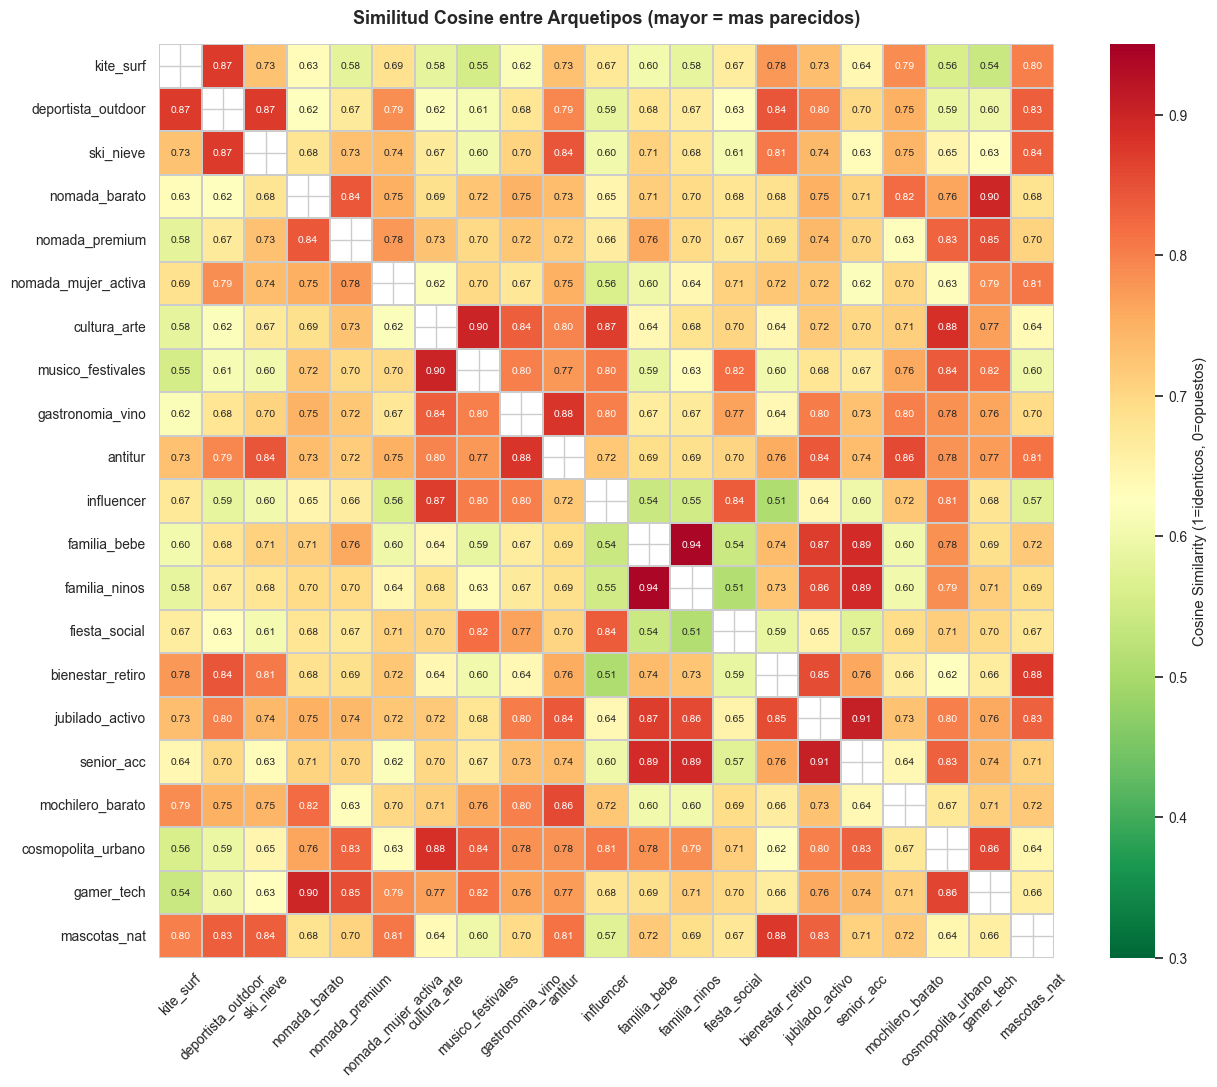

[OK] Guardado: eda_fase3_similitud_arquetipos.png


In [3]:
# Cosine similarity entre los vectores de arquetipos
matrix = df.values
sim_matrix = cosine_similarity(matrix)
df_sim = pd.DataFrame(sim_matrix, index=ARCH_LABELS, columns=ARCH_LABELS)

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.eye(21, dtype=bool)  # ocultar diagonal (cada uno = 1.0 con si mismo)

sns.heatmap(
    df_sim, ax=ax, mask=mask,
    annot=True, fmt='.2f', annot_kws={"size": 7.5},
    cmap='RdYlGn_r', vmin=0.3, vmax=0.95,
    linewidths=0.2, linecolor='#cccccc',
    cbar_kws={'label': 'Cosine Similarity (1=identicos, 0=opuestos)'}
)
ax.set_title('Similitud Cosine entre Arquetipos (mayor = mas parecidos)', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUT / 'eda_fase3_similitud_arquetipos.png', dpi=130, bbox_inches='tight')
plt.show()
print("[OK] Guardado: eda_fase3_similitud_arquetipos.png")


In [4]:
# Identificar los pares mas similares (umbral > 0.80)
pairs = []
for i in range(21):
    for j in range(i+1, 21):
        s = sim_matrix[i, j]
        if s > 0.80:
            pairs.append((ARCH_LABELS[i], ARCH_LABELS[j], round(s, 3)))

pairs.sort(key=lambda x: -x[2])
print(f"Pares con similitud > 0.80 ({len(pairs)} encontrados):")
for a, b, s in pairs:
    nivel = "⚠️  MUY SIMILAR" if s > 0.88 else "   similar"
    print(f"  {nivel}  {a:<22} ↔  {b:<22} : {s:.3f}")


Pares con similitud > 0.80 (44 encontrados):
  ⚠️  MUY SIMILAR  familia_bebe           ↔  familia_ninos          : 0.940
  ⚠️  MUY SIMILAR  jubilado_activo        ↔  senior_acc             : 0.906
  ⚠️  MUY SIMILAR  cultura_arte           ↔  musico_festivales      : 0.900
  ⚠️  MUY SIMILAR  nomada_barato          ↔  gamer_tech             : 0.897
  ⚠️  MUY SIMILAR  familia_ninos          ↔  senior_acc             : 0.893
  ⚠️  MUY SIMILAR  familia_bebe           ↔  senior_acc             : 0.889
  ⚠️  MUY SIMILAR  cultura_arte           ↔  cosmopolita_urbano     : 0.885
     similar  gastronomia_vino       ↔  antitur                : 0.880
     similar  bienestar_retiro       ↔  mascotas_nat           : 0.876
     similar  kite_surf              ↔  deportista_outdoor     : 0.873
     similar  deportista_outdoor     ↔  ski_nieve              : 0.872
     similar  familia_bebe           ↔  jubilado_activo        : 0.870
     similar  cultura_arte           ↔  influencer             : 0.8

**PARA QUE SIRVE ESTE GRAFICO:**
El mapa de similitud cosine mide qué tanto se parecen dos vectores de arquetipos.
Una similitud de 1.0 significa perfiles idénticos; 0.0 significa perfiles opuestos.

**QUE ES LA COSINE SIMILARITY:**
No mide la diferencia absoluta entre valores sino el ángulo entre los dos vectores.
Dos arquetipos con los mismos "altos y bajos" en las mismas dimensiones tendrán
similitud alta aunque los valores exactos difieran ligeramente.

**QUE NOS ESTA MOSTRANDO:**
- Las celdas rojas intensas son pares problemáticos: el modelo no podrá distinguirlos.
- Un umbral de 0.88 es alarmante: dos arquetipos con esa similitud generan casi los mismos perfiles.
- Los pares esperados similares: familia_bebe ↔ familia_ninos, nomada_barato ↔ nomada_premium,
  jubilado_activo ↔ bienestar_retiro.

**DECISION/IMPLICACION PARA EL MODELO:**
Si dos arquetipos tienen similitud > 0.90, considerar fusionarlos o añadir una dimensión
diferenciadora. No es un error automático — puede ser que dos tipos de usuario parezcan similares
por diseño y el modelo los distingue por detalles finos.


## Paso 3 — Radar charts por grupo de arquetipos


In [5]:
def radar_chart(ax, values, labels, title, colors):
    """Dibuja un radar chart para un grupo de arquetipos."""
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # cerrar el poligono

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=7)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.0'], size=6, color='grey')
    ax.set_ylim(0, 1)
    ax.set_title(title, size=10, fontweight='bold', pad=15)

    for (arch_name, arch_vals), color in zip(values.items(), colors):
        vals = arch_vals.tolist() + arch_vals.tolist()[:1]
        ax.plot(angles, vals, color=color, linewidth=1.5, linestyle='solid')
        ax.fill(angles, vals, color=color, alpha=0.1)

# Seleccionar 12 dimensiones mas informativas para los radar charts
# (las que tienen mayor varianza entre arquetipos)
variances = df.var(axis=0).sort_values(ascending=False)
top_dims = variances.head(12).index.tolist()
print("Top 12 dimensiones por varianza entre arquetipos:")
for d, v in variances.head(12).items():
    print(f"  {d:<22}: varianza = {v:.4f}")


Top 12 dimensiones por varianza entre arquetipos:
  nomada                : varianza = 0.0888
  naturaleza            : varianza = 0.0884
  vida_nocturna         : varianza = 0.0797
  calidad_vida          : varianza = 0.0758
  salud                 : varianza = 0.0702
  clima                 : varianza = 0.0696
  bienestar             : varianza = 0.0621
  autenticidad          : varianza = 0.0562
  social_media          : varianza = 0.0554
  arte_visual           : varianza = 0.0546
  turismo               : varianza = 0.0530
  comunidad             : varianza = 0.0521


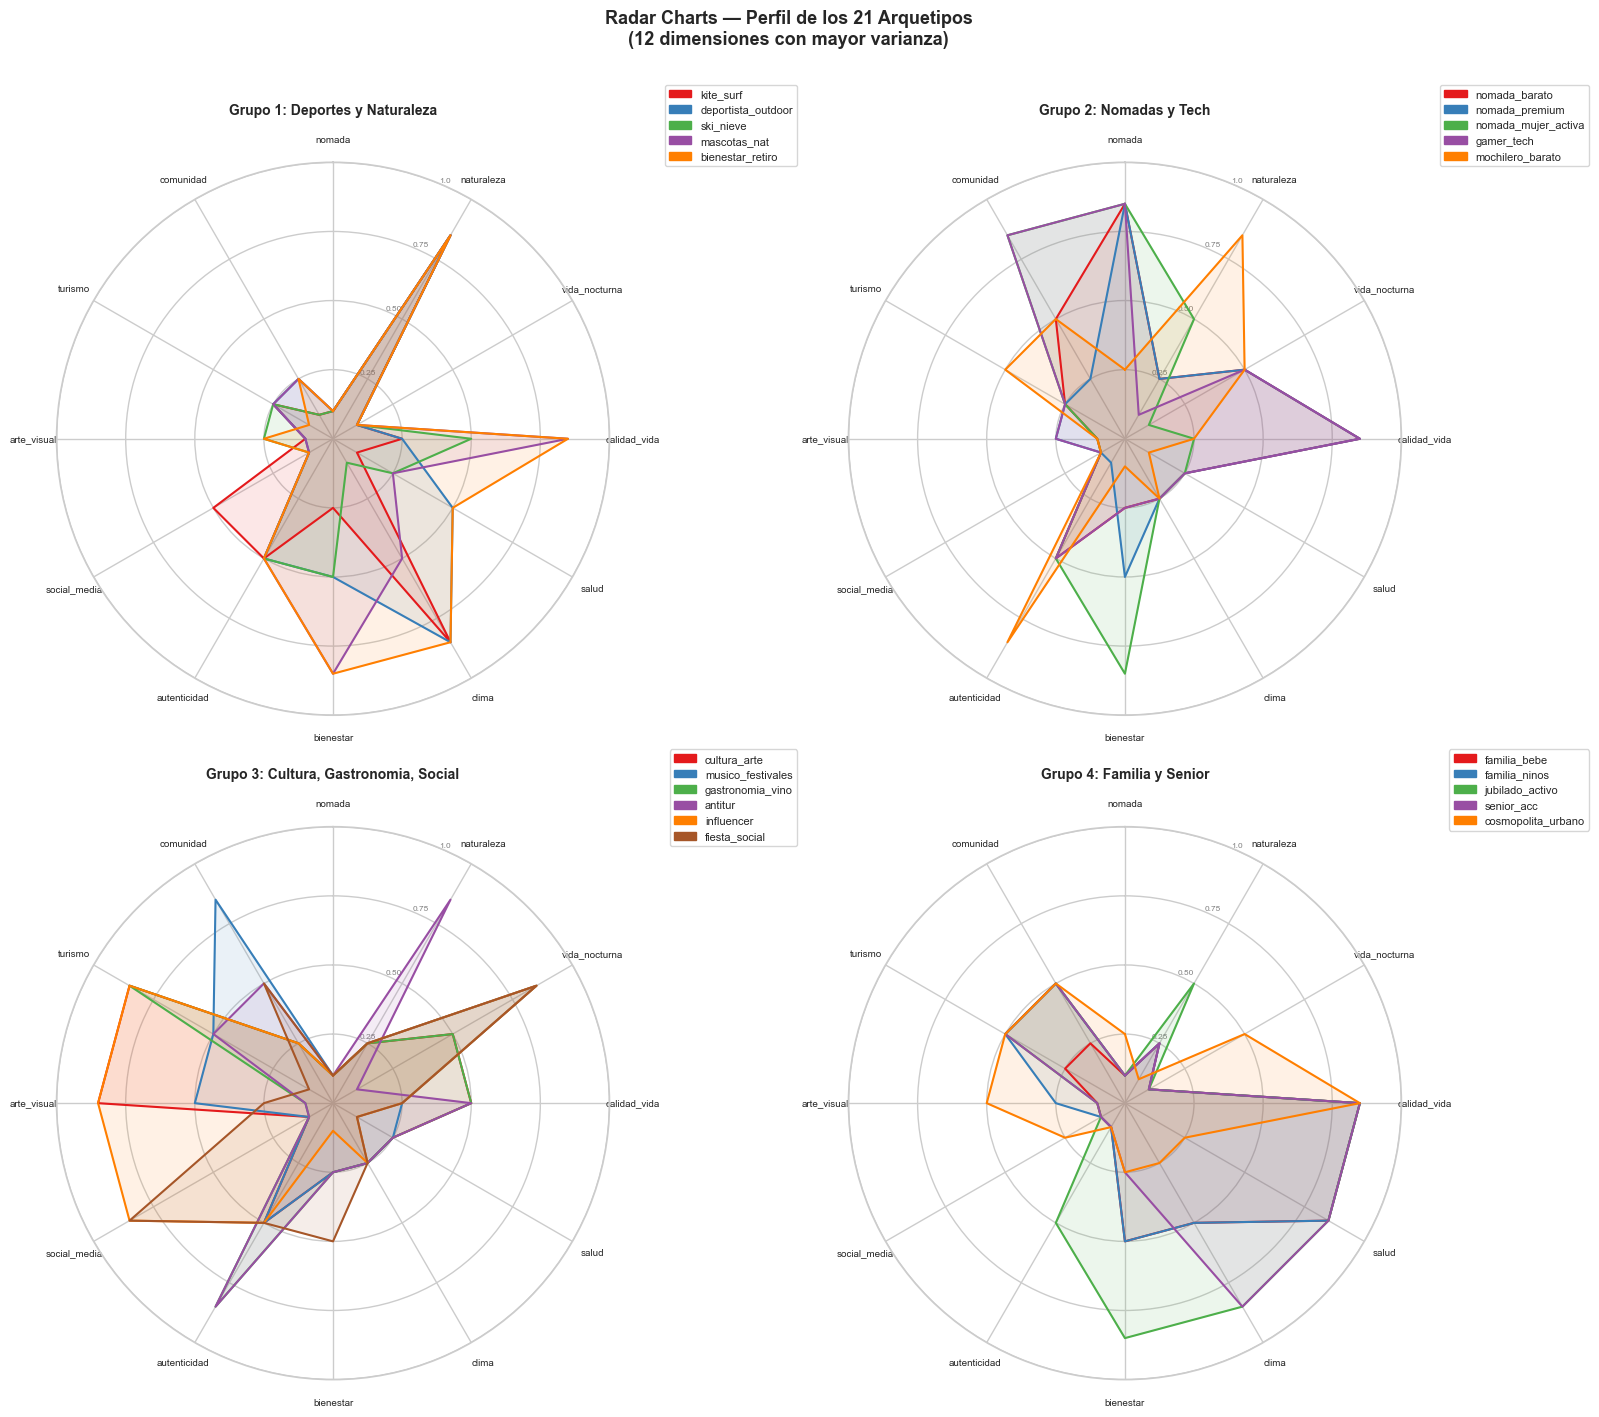

[OK] Guardado: eda_fase3_radar_arquetipos.png


In [6]:
# Grupo 1 — Deportes y naturaleza
grupo1 = ['kite_surf', 'deportista_outdoor', 'ski_nieve', 'mascotas_nat', 'bienestar_retiro']
grupo1_idx = [ARCH_LABELS.index(a) for a in grupo1]

# Grupo 2 — Nomadas y tech
grupo2 = ['nomada_barato', 'nomada_premium', 'nomada_mujer_activa', 'gamer_tech', 'mochilero_barato']
grupo2_idx = [ARCH_LABELS.index(a) for a in grupo2]

# Grupo 3 — Cultura, gastronomia, social
grupo3 = ['cultura_arte', 'musico_festivales', 'gastronomia_vino', 'antitur', 'influencer', 'fiesta_social']
grupo3_idx = [ARCH_LABELS.index(a) for a in grupo3]

# Grupo 4 — Familia y senior
grupo4 = ['familia_bebe', 'familia_ninos', 'jubilado_activo', 'senior_acc', 'cosmopolita_urbano']
grupo4_idx = [ARCH_LABELS.index(a) for a in grupo4]

COLORS = [
    '#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14), subplot_kw=dict(polar=True))

for ax, (grupo, grupo_idx, titulo) in zip(axes.flat, [
    (grupo1, grupo1_idx, "Grupo 1: Deportes y Naturaleza"),
    (grupo2, grupo2_idx, "Grupo 2: Nomadas y Tech"),
    (grupo3, grupo3_idx, "Grupo 3: Cultura, Gastronomia, Social"),
    (grupo4, grupo4_idx, "Grupo 4: Familia y Senior"),
]):
    subset = {g: df.loc[g, top_dims] for g in grupo}
    radar_chart(ax, subset, top_dims, titulo, COLORS)
    handles = [mpatches.Patch(color=COLORS[i], label=g) for i, g in enumerate(grupo)]
    ax.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

plt.suptitle('Radar Charts — Perfil de los 21 Arquetipos\n(12 dimensiones con mayor varianza)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'eda_fase3_radar_arquetipos.png', dpi=130, bbox_inches='tight')
plt.show()
print("[OK] Guardado: eda_fase3_radar_arquetipos.png")


**PARA QUE SIRVE ESTE GRAFICO:**
Los radar charts muestran el "perfil" de cada arquetipo: qué dimensiones tiene altas (lejos
del centro) y cuáles bajas (cerca del centro). Agrupamos arquetipos similares para ver si sus
perfiles se solapan visualmente.

**QUE NOS ESTA MOSTRANDO:**
- Arquetipos con formas muy similares en el radar son difíciles de distinguir para el modelo.
- Las 12 dimensiones mostradas son las que más varían entre arquetipos — las más discriminantes.
- Si dos líneas en el mismo radar se solapan completamente, esos arquetipos generarán perfiles
  casi idénticos al ejecutar el notebook 02.

**DECISION/IMPLICACION PARA EL MODELO:**
Los radares ayudan a validar cualitativamente la separación antes de mirar los números de similitud.
Un experto del dominio puede ver si "familia_bebe" y "familia_ninos" son tan parecidos que
conviene fusionarlos, o si la diferencia (educacion HIGH en familia_ninos) justifica mantenerlos.


## Paso 4 — Dendrograma jerárquico de arquetipos


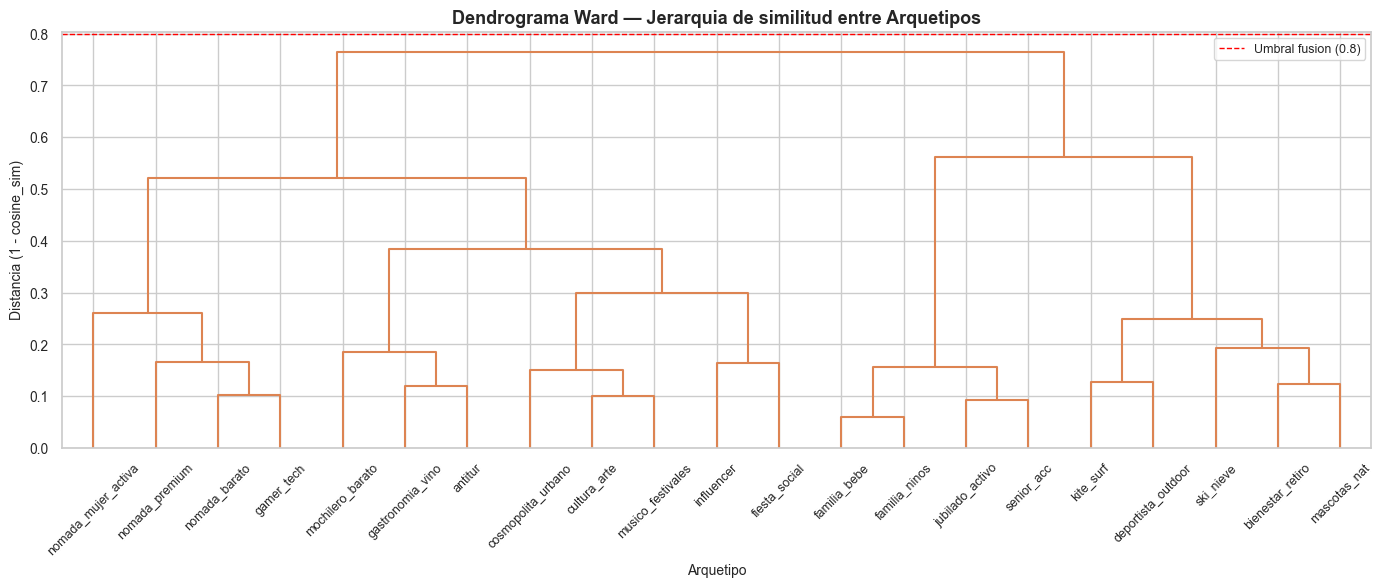

[OK] Guardado: eda_fase3_dendrograma_arquetipos.png


In [7]:
from scipy.spatial.distance import pdist

# Distancia = 1 - cosine_similarity (1 = maxima diferencia, 0 = identicos)
dist_matrix = 1 - sim_matrix
condensed = pdist(matrix, metric='cosine')

Z = linkage(condensed, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z, labels=ARCH_LABELS, ax=ax,
    color_threshold=0.8,
    leaf_rotation=45, leaf_font_size=9
)
ax.axhline(y=0.8, color='red', linestyle='--', linewidth=1, label='Umbral fusion (0.8)')
ax.set_title('Dendrograma Ward — Jerarquia de similitud entre Arquetipos', fontsize=13, fontweight='bold')
ax.set_xlabel('Arquetipo', fontsize=10)
ax.set_ylabel('Distancia (1 - cosine_sim)', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'eda_fase3_dendrograma_arquetipos.png', dpi=130, bbox_inches='tight')
plt.show()
print("[OK] Guardado: eda_fase3_dendrograma_arquetipos.png")


**PARA QUE SIRVE ESTE GRAFICO:**
El dendrograma (árbol de clustering jerárquico) muestra la estructura de similitud entre arquetipos
de forma visual: arquetipos que se "juntan" antes (más a la izquierda, branches bajos) son más
parecidos entre sí. El corte horizontal (línea roja) define el umbral a partir del cual dos arquetipos
son tan diferentes que no se fusionarían.

**QUE ES EL CLUSTERING JERARQUICO WARD:**
Ward es un método de enlace que minimiza la varianza intra-cluster al unir dos grupos. A diferencia
de average linkage (que usa la media) o complete linkage (que usa el máximo), Ward produce clusters
más compactos y equilibrados — ideal para datos de alta dimensión como vectores de preferencias.

**QUE NOS ESTA MOSTRANDO:**
- Los pares que se unen con un branch muy bajo son casi idénticos y son candidatos a fusión.
- Los clusters que aparecen son los "meta-arquetipos" naturales del dataset.
- La línea roja a distancia=0.8 marca el umbral práctico: por encima, los arquetipos son lo
  suficientemente distintos; por debajo, son candidatos a revisión.

**DECISION/IMPLICACION PARA EL MODELO:**
El número de clusters que aparecen al cortar el dendrograma indica cuántos arquetipos "realmente
distintos" hay en el sistema. Si hay 12 clusters con 21 arquetipos, algunos son redundantes.


## Paso 5 — PCA de arquetipos (visualización 2D)


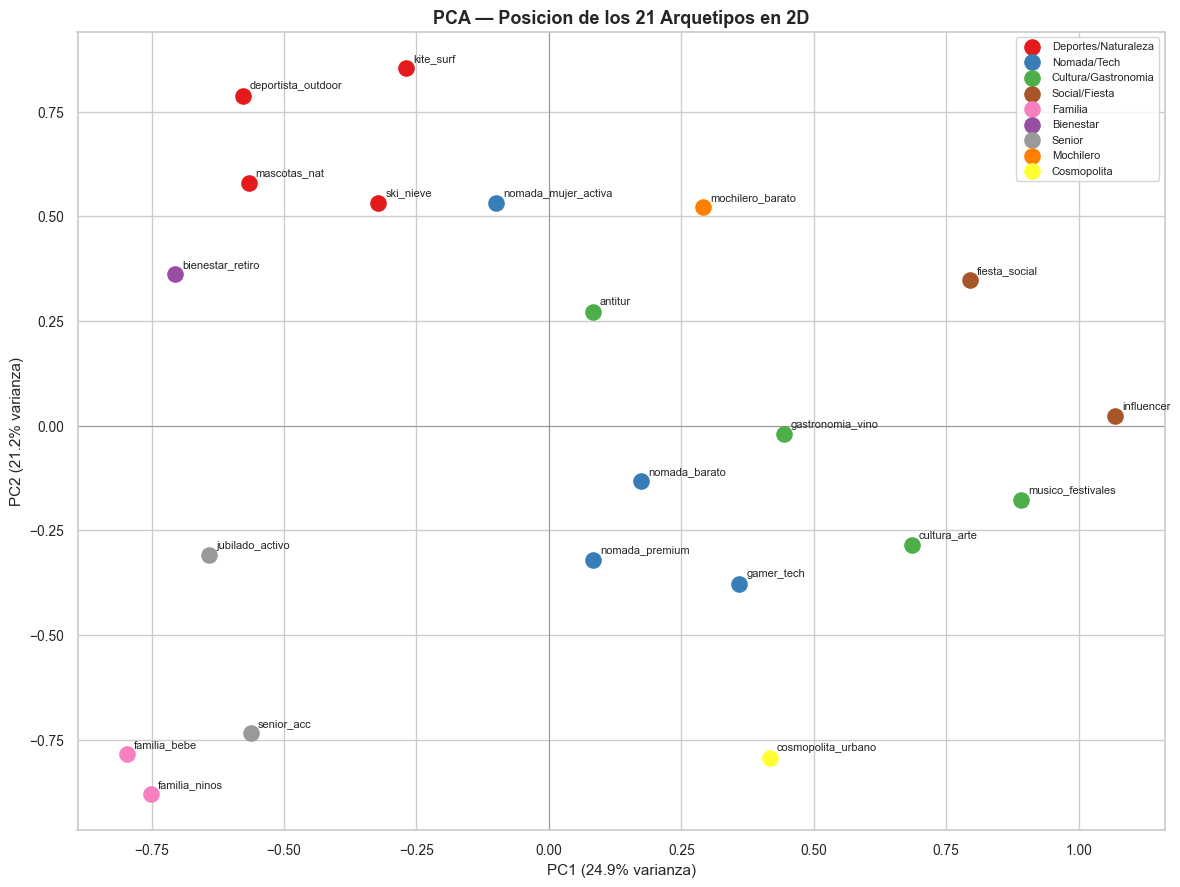

[OK] Varianza explicada: PC1=24.9%, PC2=21.2%, Total=46.1%
[OK] Guardado: eda_fase3_pca_arquetipos.png


In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(matrix)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(12, 9))

# Colorear por grupo informal
group_colors = {
    'kite_surf': '#e41a1c', 'deportista_outdoor': '#e41a1c', 'ski_nieve': '#e41a1c',
    'mascotas_nat': '#e41a1c', 'bienestar_retiro': '#984ea3',
    'nomada_barato': '#377eb8', 'nomada_premium': '#377eb8',
    'nomada_mujer_activa': '#377eb8', 'gamer_tech': '#377eb8', 'mochilero_barato': '#ff7f00',
    'cultura_arte': '#4daf4a', 'musico_festivales': '#4daf4a',
    'gastronomia_vino': '#4daf4a', 'antitur': '#4daf4a',
    'influencer': '#a65628', 'fiesta_social': '#a65628',
    'familia_bebe': '#f781bf', 'familia_ninos': '#f781bf',
    'jubilado_activo': '#999999', 'senior_acc': '#999999',
    'cosmopolita_urbano': '#ffff33',
}
group_labels = {
    '#e41a1c': 'Deportes/Naturaleza',
    '#984ea3': 'Bienestar',
    '#377eb8': 'Nomada/Tech',
    '#ff7f00': 'Mochilero',
    '#4daf4a': 'Cultura/Gastronomia',
    '#a65628': 'Social/Fiesta',
    '#f781bf': 'Familia',
    '#999999': 'Senior',
    '#ffff33': 'Cosmopolita',
}

plotted_groups = set()
for i, label in enumerate(ARCH_LABELS):
    c = group_colors.get(label, '#888888')
    gl = group_labels.get(c, '')
    lbl = gl if c not in plotted_groups else ''
    ax.scatter(coords[i, 0], coords[i, 1], c=c, s=120, zorder=3, label=lbl)
    ax.annotate(label, (coords[i, 0], coords[i, 1]),
                textcoords='offset points', xytext=(5, 5), fontsize=8)
    plotted_groups.add(c)

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('PCA — Posicion de los 21 Arquetipos en 2D', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
plt.tight_layout()
plt.savefig(OUT / 'eda_fase3_pca_arquetipos.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"[OK] Varianza explicada: PC1={var_exp[0]*100:.1f}%, PC2={var_exp[1]*100:.1f}%, Total={sum(var_exp)*100:.1f}%")
print("[OK] Guardado: eda_fase3_pca_arquetipos.png")


**PARA QUE SIRVE ESTE GRAFICO:**
El PCA proyecta los 26 vectores de dimensión a 2D conservando la máxima varianza posible.
Cada punto es un arquetipo. La distancia entre dos puntos indica su diferencia en el espacio
de preferencias — puntos cercanos = arquetipos similares.

**QUE ES PCA (recordatorio):**
Principal Component Analysis encuentra los ejes de máxima varianza en datos de alta dimensión
y proyecta sobre los primeros dos. No es exacto (pierde información), pero permite ver la
estructura global del espacio en una imagen.

**QUE NOS ESTA MOSTRANDO:**
- Los puntos más cercanos son pares problemáticos (también confirmados en el mapa de similitud).
- Los puntos en los extremos son los arquetipos más únicos — el modelo los diferenciará mejor.
- El % de varianza explicado indica cuánta información conserva la proyección 2D.

**DECISION/IMPLICACION PARA EL MODELO:**
Si dos arquetipos aparecen muy juntos en el PCA Y tienen similitud > 0.88 en el mapa de similitud,
hay una evidencia doble de que son redundantes.


## Paso 6 — ¿Qué dimensiones separan mejor los arquetipos?


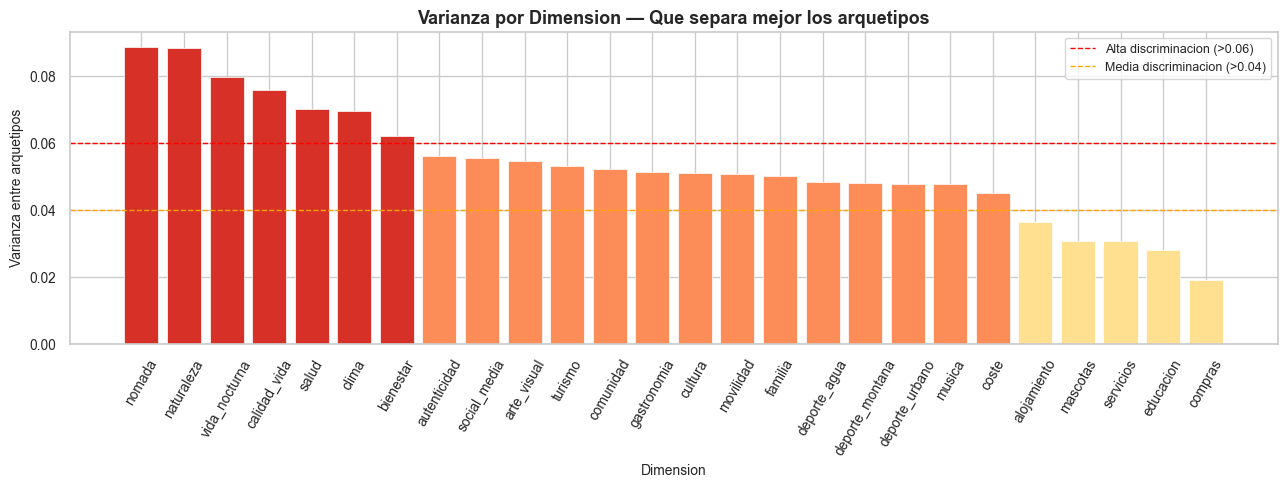

Top 8 dimensiones MAS discriminantes (mayor varianza):
  nomada                : 0.0888
  naturaleza            : 0.0884
  vida_nocturna         : 0.0797
  calidad_vida          : 0.0758
  salud                 : 0.0702
  clima                 : 0.0696
  bienestar             : 0.0621
  autenticidad          : 0.0562

Bottom 5 dimensiones MENOS discriminantes (menor varianza):
  alojamiento           : 0.0363
  mascotas              : 0.0307
  servicios             : 0.0305
  educacion             : 0.0279
  compras               : 0.0191


In [9]:
# Varianza de cada dimension entre los 21 arquetipos
var_by_dim = df.var(axis=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
colors_bar = ['#d73027' if v > 0.06 else '#fc8d59' if v > 0.04 else '#fee090' for v in var_by_dim]
ax.bar(var_by_dim.index, var_by_dim.values, color=colors_bar, edgecolor='white', linewidth=0.5)
ax.set_title('Varianza por Dimension — Que separa mejor los arquetipos', fontsize=13, fontweight='bold')
ax.set_xlabel('Dimension', fontsize=10)
ax.set_ylabel('Varianza entre arquetipos', fontsize=10)
ax.tick_params(axis='x', rotation=60)
ax.axhline(0.06, color='red', linestyle='--', linewidth=1, label='Alta discriminacion (>0.06)')
ax.axhline(0.04, color='orange', linestyle='--', linewidth=1, label='Media discriminacion (>0.04)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'eda_fase3_varianza_dimensiones.png', dpi=130, bbox_inches='tight')
plt.show()

print("Top 8 dimensiones MAS discriminantes (mayor varianza):")
for d, v in var_by_dim.head(8).items():
    print(f"  {d:<22}: {v:.4f}")
print()
print("Bottom 5 dimensiones MENOS discriminantes (menor varianza):")
for d, v in var_by_dim.tail(5).items():
    print(f"  {d:<22}: {v:.4f}")


**PARA QUE SIRVE ESTE GRAFICO:**
La varianza de una dimension entre los 21 arquetipos mide cuánto varía su importancia de
un arquetipo a otro. Una varianza alta significa que esta dimension diferencia bien los arquetipos
(unos la tienen alta, otros baja). Una varianza baja significa que todos los arquetipos la valoran
parecido — es poco útil para distinguir usuarios.

**QUE NOS ESTA MOSTRANDO:**
- Las dimensiones rojas son las más discriminantes — las que el modelo usará más para separar usuarios.
- Las dimensiones amarillas tienen poca varianza entre arquetipos — todos los usuarios las valoran igual.
- Si "alojamiento" o "compras" tienen varianza muy baja, quizás no discriminan bien y deberían
  revisarse en el diseño de los arquetipos.

**DECISION/IMPLICACION PARA EL MODELO:**
Las dimensiones con varianza muy baja son candidatas a revisar. Si ningún arquetipo las pone
como HIGH, el modelo nunca aprenderá que esa dimensión importa — aunque sea relevante para
algunos usuarios reales.


## Resumen — ¿Están bien diferenciados los 21 arquetipos?


In [10]:
print("=" * 65)
print("  RESUMEN EDA FASE 3 — DIFERENCIACION DE ARQUETIPOS")
print("=" * 65)
print()

# 1. Similitud media
upper_tri = sim_matrix[np.triu_indices(21, k=1)]
print(f"Similitud cosine media entre arquetipos: {upper_tri.mean():.3f}")
print(f"Similitud cosine maxima (sin diagonal):   {upper_tri.max():.3f}")
print(f"Similitud cosine minima:                  {upper_tri.min():.3f}")
print()

# 2. Pares criticos
pares_altos = [(ARCH_LABELS[i], ARCH_LABELS[j], sim_matrix[i,j])
               for i in range(21) for j in range(i+1, 21)
               if sim_matrix[i,j] > 0.85]
pares_altos.sort(key=lambda x: -x[2])
if pares_altos:
    print(f"Pares con similitud > 0.85 ({len(pares_altos)} pares):")
    for a, b, s in pares_altos:
        print(f"  {a:<25} <-> {b:<25}: {s:.3f}  {'REVISAR' if s>0.90 else 'OK'}")
else:
    print("No hay pares con similitud > 0.85 — todos los arquetipos estan bien diferenciados.")
print()

# 3. Dimensiones criticas
var_by_dim = df.var(axis=0).sort_values(ascending=False)
baja_varianza = var_by_dim[var_by_dim < 0.025]
print(f"Dimensiones con varianza muy baja (<0.025) — poco discriminantes ({len(baja_varianza)}):")
for d, v in baja_varianza.items():
    print(f"  {d:<22}: {v:.4f}")
print()
print("CONCLUSION:")
if upper_tri.max() > 0.92:
    print("  ATENCION: hay pares de arquetipos muy similares. Considerar fusion o diferenciacion.")
elif upper_tri.max() > 0.85:
    print("  ADVERTENCIA: algunos pares son bastante similares. Revisar si la diferenciacion es suficiente.")
else:
    print("  OK: todos los arquetipos estan suficientemente diferenciados para generar perfiles sinteticos.")
print()
print("Siguiente paso: si la diferenciacion es aceptable, proceder con notebook 02 para")
print("generar los 5.000 perfiles sinteticos de entrenamiento.")


  RESUMEN EDA FASE 3 — DIFERENCIACION DE ARQUETIPOS

Similitud cosine media entre arquetipos: 0.715
Similitud cosine maxima (sin diagonal):   0.940
Similitud cosine minima:                  0.508

Pares con similitud > 0.85 (18 pares):
  familia_bebe              <-> familia_ninos            : 0.940  REVISAR
  jubilado_activo           <-> senior_acc               : 0.906  REVISAR
  cultura_arte              <-> musico_festivales        : 0.900  REVISAR
  nomada_barato             <-> gamer_tech               : 0.897  OK
  familia_ninos             <-> senior_acc               : 0.893  OK
  familia_bebe              <-> senior_acc               : 0.889  OK
  cultura_arte              <-> cosmopolita_urbano       : 0.885  OK
  gastronomia_vino          <-> antitur                  : 0.880  OK
  bienestar_retiro          <-> mascotas_nat             : 0.876  OK
  kite_surf                 <-> deportista_outdoor       : 0.873  OK
  deportista_outdoor        <-> ski_nieve                : 

**CONCLUSION DUAL**

**Para el modelo:**
Un arquetipo correctamente diferenciado garantiza que el modelo vea suficiente variedad en los
datos de entrenamiento. Si familia_bebe y familia_ninos tienen similitud 0.93, el 80% de sus
perfiles sintéticos serán prácticamente iguales — el modelo aprenderá casi lo mismo de ambos y
uno de ellos aportará poco valor al entrenamiento.

**Para la presentación del bootcamp:**
Este análisis demuestra que el proyecto no solo genera datos artificiales — los valida con métricas
concretas (cosine similarity, varianza entre arquetipos) antes de entrenar. Es la diferencia entre
"generé 5.000 usuarios aleatorios" y "diseñé 21 arquetipos y verifiqué que están suficientemente
diferenciados para que el modelo pueda aprender patrones distintos de cada uno".
